In [ ]:
from google.colab import userdata
from google import genai

api_key = userdata.get('GEMINI_API_KEY')
client = genai.Client(api_key=api_key)

response = client.models.generate_content(
    model="gemini-1.5-flash-latest",
    contents="Say hello in one sentence!"
)

print("✅ Gemini API works!")
print("Response:", response.text)

ClientError: 401 UNAUTHENTICATED. {'error': {'code': 401, 'message': 'Request had invalid authentication credentials. Expected OAuth 2 access token, login cookie or other valid authentication credential. See https://developers.google.com/identity/sign-in/web/devconsole-project.', 'status': 'UNAUTHENTICATED', 'details': [{'@type': 'type.googleapis.com/google.rpc.ErrorInfo', 'reason': 'ACCESS_TOKEN_TYPE_UNSUPPORTED', 'metadata': {'service': 'generativelanguage.googleapis.com', 'method': 'google.ai.generativelanguage.v1beta.GenerativeService.GenerateContent'}}]}}

In [ ]:
import os
files = os.listdir('/content')
files.sort()
for f in files:
    if not os.path.isdir(f'/content/{f}'):
        print(f"✅ {f}")

In [ ]:
import os
files = os.listdir('/content')
files.sort()
print("Files in Colab:")
for f in files:
    if not os.path.isdir(f'/content/{f}'):
        print(f"  ✅ {f}")

Files in Colab:


In [ ]:
!pip install -q spacy textblob
!python -m spacy download en_core_web_sm -q

import re
import pandas as pd
import numpy as np
import spacy

nlp = spacy.load("en_core_web_sm")

# Upload master_dataset.csv first!
# Click 📁 → upload → master_dataset.csv
df = pd.read_csv('master_dataset.csv')

def calculate_ttr(text):
    words = str(text).lower().split()
    return len(set(words)) / len(words) if words else 0

def calculate_hapax(text):
    words = str(text).lower().split()[:5000]
    freq = {}
    for w in words:
        freq[w] = freq.get(w, 0) + 1
    return sum(1 for c in freq.values() if c == 1)

def avg_sentence_length(text):
    sentences = [s for s in str(text).split('.') if s.strip()]
    return np.mean([len(s.split()) for s in sentences]) if sentences else 0

def avg_word_length(text):
    words = str(text).split()
    return np.mean([len(w) for w in words]) if words else 0

def punctuation_features(text):
    text = str(text)
    total = len(text) + 1
    return {
        'semicolons': text.count(';') / total * 1000,
        'exclamations': text.count('!') / total * 1000,
        'dashes': (text.count('—') + text.count(' - ')) / total * 1000,
        'commas': text.count(',') / total * 1000,
        'periods': text.count('.') / total * 1000,
        'question_marks': text.count('?') / total * 1000,
    }

def count_syl(word):
    word = word.lower()
    vowels = "aeiou"
    count = 0
    prev = False
    for char in word:
        is_v = char in vowels
        if is_v and not prev:
            count += 1
        prev = is_v
    if word.endswith('e'):
        count -= 1
    return max(1, count)

def flesch_kincaid(text):
    sentences = [s for s in str(text).split('.') if s.strip()]
    words = str(text).split()
    if not sentences or not words:
        return 0
    syllables = sum(count_syl(w) for w in words)
    return max(0, 0.39*(len(words)/len(sentences)) + 11.8*(syllables/len(words)) - 15.59)

def pos_adj_noun(text):
    doc = nlp(str(text)[:500])
    adj = sum(1 for t in doc if t.pos_ == 'ADJ')
    noun = sum(1 for t in doc if t.pos_ == 'NOUN')
    return adj/noun if noun > 0 else 0

def dep_depth(text):
    doc = nlp(str(text)[:500])
    depths = []
    for token in doc:
        depth = 0
        current = token
        while current.head != current:
            depth += 1
            current = current.head
        depths.append(depth)
    return np.mean(depths) if depths else 0

print("Extracting features... (3-4 mins)")
df['ttr'] = df['text'].apply(calculate_ttr)
df['hapax'] = df['text'].apply(calculate_hapax)
df['avg_sentence_length'] = df['text'].apply(avg_sentence_length)
df['avg_word_length'] = df['text'].apply(avg_word_length)

punct = df['text'].apply(punctuation_features)
punct_df = pd.DataFrame(punct.tolist())
for col in punct_df.columns:
    df[col] = punct_df[col]

df['flesch_kincaid'] = df['text'].apply(flesch_kincaid)
df['adj_noun_ratio'] = df['text'].apply(pos_adj_noun)
df['dep_tree_depth'] = df['text'].apply(dep_depth)

df.to_csv('features.csv', index=False)
print("✅ features.csv regenerated!")
print(f"Shape: {df.shape}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 33.8 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
Extracting features... (3-4 mins)
✅ features.csv regenerated!
Shape: (1500, 17)


In [ ]:
# DAY 2 SETUP - Run this first!
!pip install -q groq spacy textblob
!python -m spacy download en_core_web_sm -q

import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("✅ Libraries loaded!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.7/143.7 kB 6.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 119.3 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
✅ Libraries loaded!


In [ ]:
!pip install -q groq spacy textblob
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import spacy

nlp = spacy.load("en_core_web_sm")

# Load master dataset
df = pd.read_csv('master_dataset.csv')

print("✅ Everything loaded!")
print(f"Dataset shape: {df.shape}")
print(f"\nClass distribution:")
print(df['class'].value_counts())

✅ Everything loaded!
Dataset shape: (1500, 4)

Class distribution:
class
Human        500
GenericAI    500
StyleAI      500
Name: count, dtype: int64


In [ ]:
# ============================================
# TASK 1: LEXICAL RICHNESS
# ============================================

def calculate_ttr(text):
    words = str(text).lower().split()
    if len(words) == 0:
        return 0
    return len(set(words)) / len(words)

def calculate_hapax(text, sample_size=5000):
    words = str(text).lower().split()[:sample_size]
    freq = {}
    for word in words:
        freq[word] = freq.get(word, 0) + 1
    return sum(1 for count in freq.values() if count == 1)

def avg_sentence_length(text):
    sentences = str(text).split('.')
    lengths = [len(s.split()) for s in sentences if len(s.split()) > 0]
    return np.mean(lengths) if lengths else 0

def avg_word_length(text):
    words = str(text).split()
    return np.mean([len(w) for w in words]) if words else 0

# Apply to all 1500 samples
print("Extracting lexical features... (takes 1-2 mins)")

df['ttr'] = df['text'].apply(calculate_ttr)
df['hapax'] = df['text'].apply(calculate_hapax)
df['avg_sentence_length'] = df['text'].apply(avg_sentence_length)
df['avg_word_length'] = df['text'].apply(avg_word_length)

print("✅ Lexical features done!")
print("\nMean TTR by class:")
print(df.groupby('class')['ttr'].mean().round(4))
print("\nMean Hapax by class:")
print(df.groupby('class')['hapax'].mean().round(2))

Extracting lexical features... (takes 1-2 mins)
✅ Lexical features done!

Mean TTR by class:
class
GenericAI    0.6941
Human        0.7445
StyleAI      0.7053
Name: ttr, dtype: float64

Mean Hapax by class:
class
GenericAI    78.48
Human        64.51
StyleAI      80.17
Name: hapax, dtype: float64


In [ ]:
# ============================================
# TASK 1: PUNCTUATION DENSITY
# ============================================

def punctuation_features(text):
    text = str(text)
    total_chars = len(text) + 1
    return {
        'semicolons': text.count(';') / total_chars * 1000,
        'exclamations': text.count('!') / total_chars * 1000,
        'dashes': (text.count('—') + text.count(' - ')) / total_chars * 1000,
        'commas': text.count(',') / total_chars * 1000,
        'periods': text.count('.') / total_chars * 1000,
        'question_marks': text.count('?') / total_chars * 1000,
    }

print("Extracting punctuation features...")

punct_features = df['text'].apply(punctuation_features)
punct_df = pd.DataFrame(punct_features.tolist())

for col in punct_df.columns:
    df[col] = punct_df[col]

print("✅ Punctuation features done!")
print("\nMean punctuation by class:")
print(df.groupby('class')[['semicolons','exclamations','dashes','commas','periods']].mean().round(4))

Extracting punctuation features...
✅ Punctuation features done!

Mean punctuation by class:
           semicolons  exclamations  dashes   commas  periods
class                                                        
GenericAI      0.0021        0.0000  0.0000  11.3932   6.5802
Human          1.8075        0.8597  0.6478  15.8511   9.2642
StyleAI        0.1471        0.0235  0.1467  15.7113   5.3585


In [ ]:
# ============================================
# TASK 1: READABILITY + POS FEATURES
# ============================================

import nltk
nltk.download('punkt', quiet=True)
nltk.download('averaged_perceptron_tagger_eng', quiet=True)

def count_syllables(word):
    word = word.lower()
    vowels = "aeiou"
    count = 0
    prev_vowel = False
    for char in word:
        is_vowel = char in vowels
        if is_vowel and not prev_vowel:
            count += 1
        prev_vowel = is_vowel
    if word.endswith('e'):
        count -= 1
    return max(1, count)

def flesch_kincaid(text):
    sentences = [s.strip() for s in str(text).split('.') if len(s.strip()) > 0]
    words = str(text).split()
    if len(sentences) == 0 or len(words) == 0:
        return 0
    syllables = sum(count_syllables(w) for w in words)
    grade = 0.39 * (len(words)/len(sentences)) + 11.8 * (syllables/len(words)) - 15.59
    return max(0, grade)

def pos_adj_noun_ratio(text):
    doc = nlp(str(text)[:500])
    adj = sum(1 for token in doc if token.pos_ == 'ADJ')
    noun = sum(1 for token in doc if token.pos_ == 'NOUN')
    return adj / noun if noun > 0 else 0

def dep_tree_depth(text):
    doc = nlp(str(text)[:500])
    depths = []
    for token in doc:
        depth = 0
        current = token
        while current.head != current:
            depth += 1
            current = current.head
        depths.append(depth)
    return np.mean(depths) if depths else 0

print("Extracting readability + POS features...")
print("(This takes 3-4 minutes, SpaCy is processing...)\n")

df['flesch_kincaid'] = df['text'].apply(flesch_kincaid)
print("✅ Flesch-Kincaid done!")

df['adj_noun_ratio'] = df['text'].apply(pos_adj_noun_ratio)
print("✅ POS ratio done!")

df['dep_tree_depth'] = df['text'].apply(dep_tree_depth)
print("✅ Dependency depth done!")

print("\nResults by class:")
print(df.groupby('class')[['flesch_kincaid','adj_noun_ratio','dep_tree_depth']].mean().round(4))

Extracting readability + POS features...
(This takes 3-4 minutes, SpaCy is processing...)

✅ Flesch-Kincaid done!
✅ POS ratio done!
✅ Dependency depth done!

Results by class:
           flesch_kincaid  adj_noun_ratio  dep_tree_depth
class                                                    
GenericAI         16.4283          0.4097          3.0268
Human              8.4149          0.4474          2.6045
StyleAI           16.0621          0.4534          3.4053


✅ Features saved!
Total features per sample: 17
Columns: ['text', 'topic', 'author_style', 'class', 'ttr', 'hapax', 'avg_sentence_length', 'avg_word_length', 'semicolons', 'exclamations', 'dashes', 'commas', 'periods', 'question_marks', 'flesch_kincaid', 'adj_noun_ratio', 'dep_tree_depth']


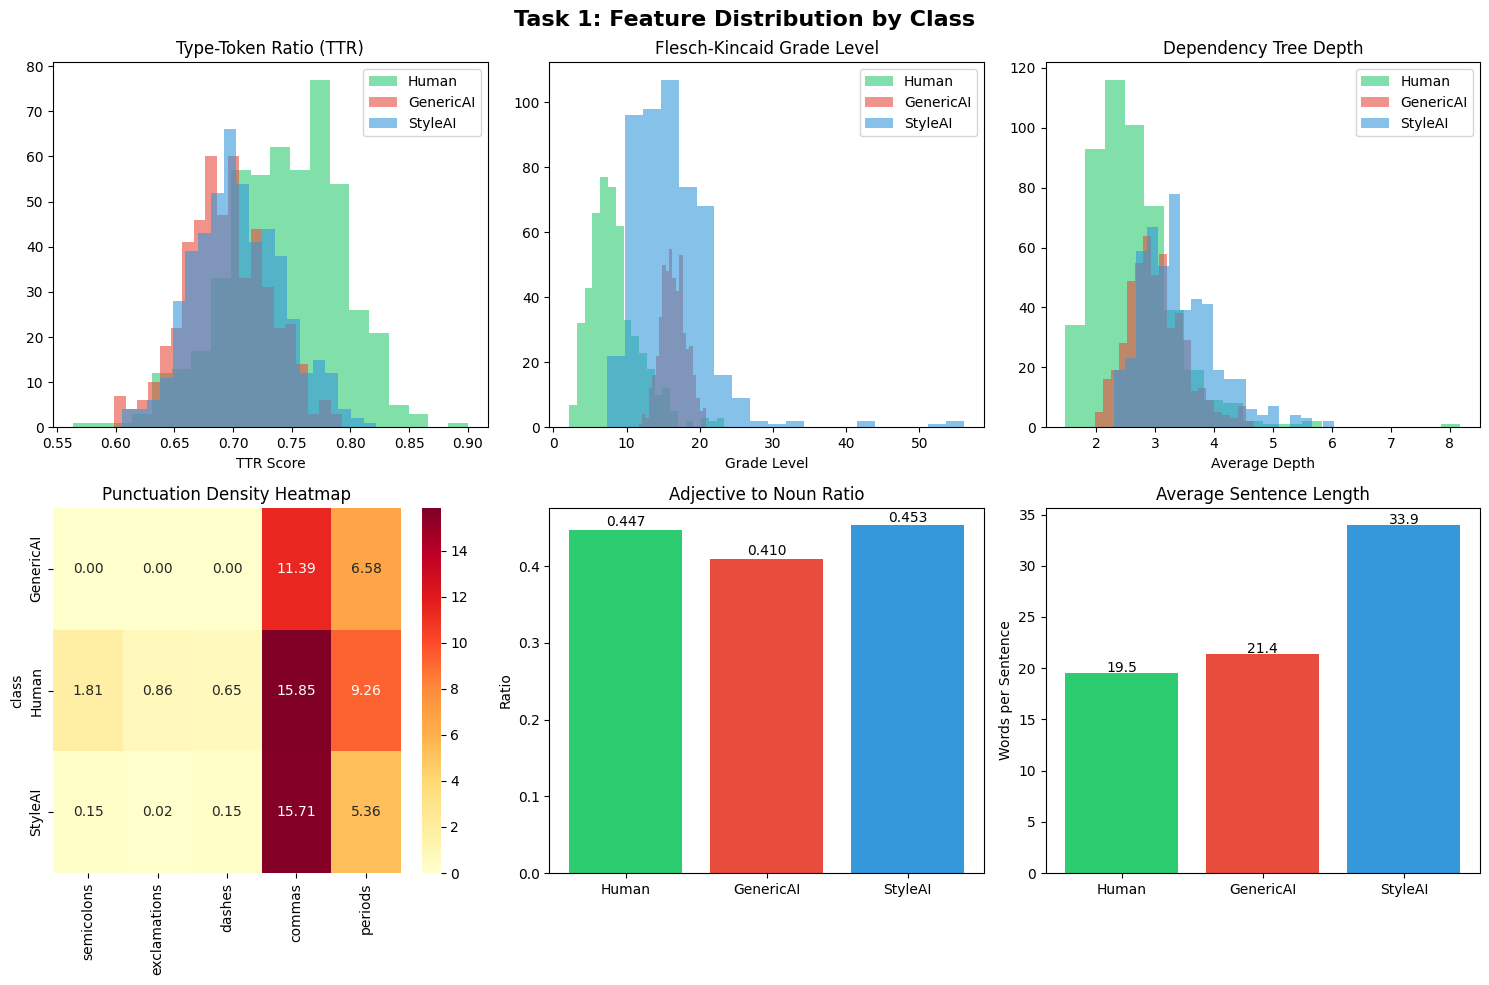

✅ Visualizations saved as task1_features.png!


In [ ]:
# Save feature dataset
df.to_csv('features.csv', index=False)
print("✅ Features saved!")
print(f"Total features per sample: {len(df.columns)}")
print(f"Columns: {list(df.columns)}")

# ============================================
# VISUALIZATIONS
# ============================================

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Task 1: Feature Distribution by Class', fontsize=16, fontweight='bold')

colors = {'Human': '#2ecc71', 'GenericAI': '#e74c3c', 'StyleAI': '#3498db'}

# Plot 1: TTR
ax1 = axes[0, 0]
for cls in ['Human', 'GenericAI', 'StyleAI']:
    data = df[df['class'] == cls]['ttr']
    ax1.hist(data, alpha=0.6, label=cls, color=colors[cls], bins=20)
ax1.set_title('Type-Token Ratio (TTR)')
ax1.set_xlabel('TTR Score')
ax1.legend()

# Plot 2: Flesch-Kincaid
ax2 = axes[0, 1]
for cls in ['Human', 'GenericAI', 'StyleAI']:
    data = df[df['class'] == cls]['flesch_kincaid']
    ax2.hist(data, alpha=0.6, label=cls, color=colors[cls], bins=20)
ax2.set_title('Flesch-Kincaid Grade Level')
ax2.set_xlabel('Grade Level')
ax2.legend()

# Plot 3: Dependency Tree Depth
ax3 = axes[0, 2]
for cls in ['Human', 'GenericAI', 'StyleAI']:
    data = df[df['class'] == cls]['dep_tree_depth']
    ax3.hist(data, alpha=0.6, label=cls, color=colors[cls], bins=20)
ax3.set_title('Dependency Tree Depth')
ax3.set_xlabel('Average Depth')
ax3.legend()

# Plot 4: Punctuation Heatmap
ax4 = axes[1, 0]
punct_cols = ['semicolons', 'exclamations', 'dashes', 'commas', 'periods']
pivot = df.groupby('class')[punct_cols].mean()
sns.heatmap(pivot, annot=True, fmt='.2f', cmap='YlOrRd', ax=ax4)
ax4.set_title('Punctuation Density Heatmap')

# Plot 5: Adj/Noun Ratio
ax5 = axes[1, 1]
classes = ['Human', 'GenericAI', 'StyleAI']
means = [df[df['class']==c]['adj_noun_ratio'].mean() for c in classes]
bars = ax5.bar(classes, means, color=[colors[c] for c in classes])
ax5.set_title('Adjective to Noun Ratio')
ax5.set_ylabel('Ratio')
for bar, mean in zip(bars, means):
    ax5.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{mean:.3f}', ha='center', fontsize=10)

# Plot 6: Avg Sentence Length
ax6 = axes[1, 2]
means2 = [df[df['class']==c]['avg_sentence_length'].mean() for c in classes]
bars2 = ax6.bar(classes, means2, color=[colors[c] for c in classes])
ax6.set_title('Average Sentence Length')
ax6.set_ylabel('Words per Sentence')
for bar, mean in zip(bars2, means2):
    ax6.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             f'{mean:.1f}', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('task1_features.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Visualizations saved as task1_features.png!")

Classes: ['GenericAI' 'Human' 'StyleAI']
Train size: 1200, Test size: 300

TIER A (XGBoost) RESULTS
Accuracy: 0.9833 (98.3%)

Detailed Report:
              precision    recall  f1-score   support

   GenericAI       0.98      1.00      0.99       100
       Human       0.99      0.98      0.98       100
     StyleAI       0.98      0.97      0.97       100

    accuracy                           0.98       300
   macro avg       0.98      0.98      0.98       300
weighted avg       0.98      0.98      0.98       300



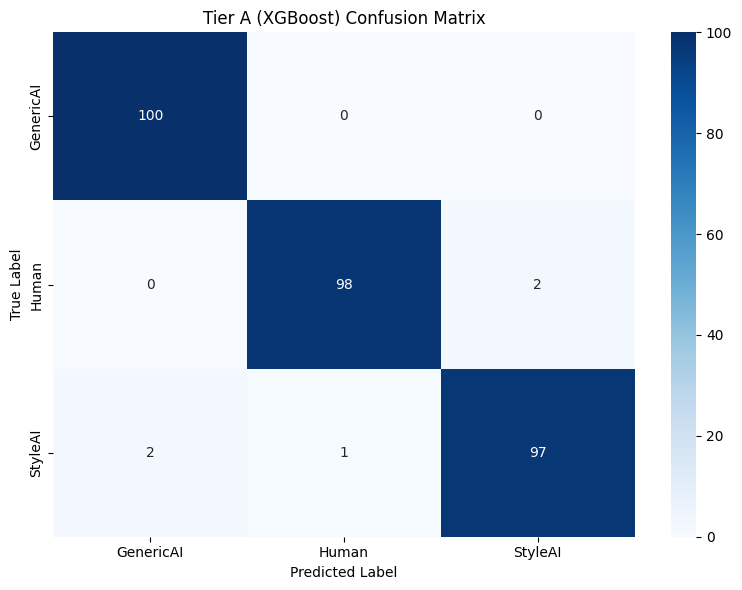

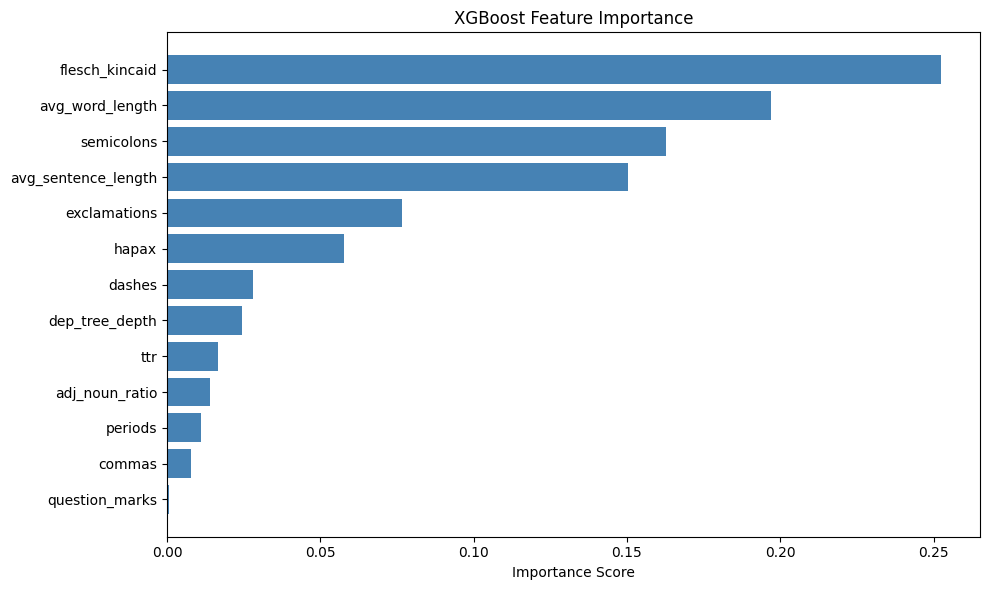


✅ Tier A complete! Model saved!


In [ ]:
# ============================================
# TASK 2 - TIER A: XGBoost Classifier
# ============================================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from xgboost import XGBClassifier
import joblib
import seaborn as sns

# Load features
df = pd.read_csv('features.csv')

# Select only numerical features
feature_cols = ['ttr', 'hapax', 'avg_sentence_length', 'avg_word_length',
                'semicolons', 'exclamations', 'dashes', 'commas', 'periods',
                'question_marks', 'flesch_kincaid', 'adj_noun_ratio', 'dep_tree_depth']

X = df[feature_cols]
y = df['class']

# Encode labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)
print(f"Classes: {le.classes_}")

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")

# Train XGBoost
model_a = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    random_state=42,
    eval_metric='mlogloss'
)

model_a.fit(X_train, y_train)

# Evaluate
y_pred = model_a.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print(f"\n{'='*45}")
print(f"TIER A (XGBoost) RESULTS")
print(f"{'='*45}")
print(f"Accuracy: {acc:.4f} ({acc*100:.1f}%)")
print(f"\nDetailed Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

# Confusion Matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Tier A (XGBoost) Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('tier_a_confusion_matrix.png', dpi=150)
plt.show()

# Feature Importance
plt.figure(figsize=(10, 6))
importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': model_a.feature_importances_
}).sort_values('importance', ascending=True)

plt.barh(importance_df['feature'], importance_df['importance'], color='steelblue')
plt.title('XGBoost Feature Importance')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('tier_a_feature_importance.png', dpi=150)
plt.show()

# Save model
joblib.dump(model_a, 'tier_a_xgboost.pkl')
joblib.dump(le, 'label_encoder.pkl')
print("\n✅ Tier A complete! Model saved!")

✅ GloVe downloaded!
Loading GloVe vectors...
✅ Loaded 400,000 word vectors!
Converting texts to embeddings...
✅ Embeddings shape: (1500, 50)

Using device: cuda

Training Neural Network...
Epoch 20/100, Loss: 0.3942
Epoch 40/100, Loss: 0.1761
Epoch 60/100, Loss: 0.0304
Epoch 80/100, Loss: 0.0246
Epoch 100/100, Loss: 0.0234

TIER B (Neural Network) RESULTS
Accuracy: 0.9967 (99.7%)

Detailed Report:
              precision    recall  f1-score   support

   GenericAI       1.00      1.00      1.00        86
       Human       1.00      0.99      1.00       104
     StyleAI       0.99      1.00      1.00       110

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300



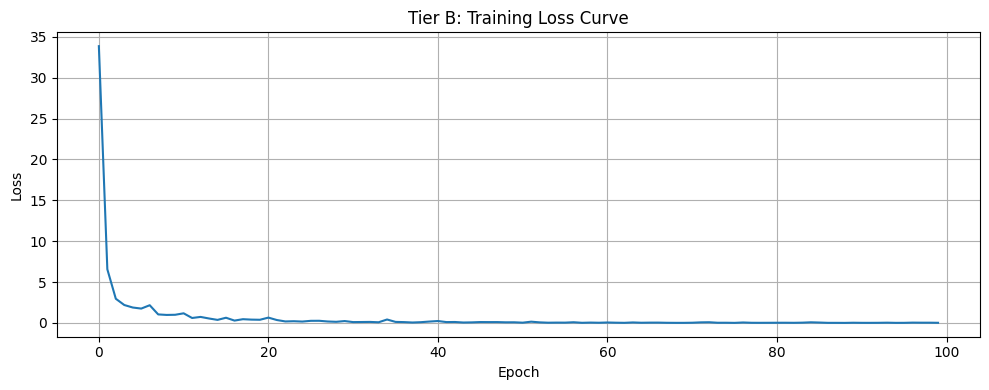

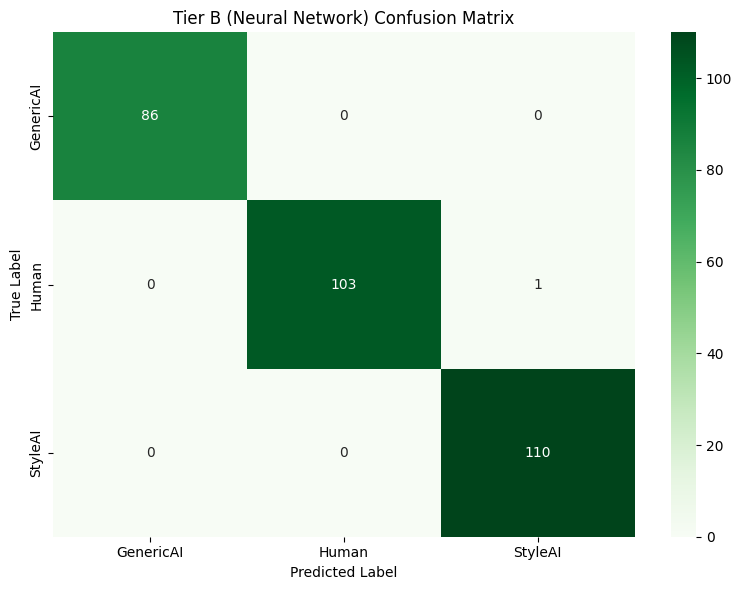


✅ Tier B complete! Model saved!


In [ ]:
# ============================================
# TASK 2 - TIER B: Neural Network with GloVe
# ============================================

import torch
import torch.nn as nn
import numpy as np
from torch.utils.data import DataLoader, TensorDataset
import urllib.request
import zipfile
import os

# Download GloVe embeddings (50d - smaller and faster)
print("Downloading GloVe embeddings... (this takes 2-3 mins)")

if not os.path.exists('glove.6B.50d.txt'):
    urllib.request.urlretrieve(
        'https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip',
        'glove.6B.zip'
    )
    with zipfile.ZipFile('glove.6B.zip', 'r') as f:
        f.extract('glove.6B.50d.txt')
    print("✅ GloVe downloaded!")
else:
    print("✅ GloVe already exists!")

# Load GloVe
print("Loading GloVe vectors...")
glove = {}
with open('glove.6B.50d.txt', 'r', encoding='utf-8') as f:
    for line in f:
        values = line.split()
        word = values[0]
        vector = np.array(values[1:], dtype='float32')
        glove[word] = vector

print(f"✅ Loaded {len(glove):,} word vectors!")

# Convert texts to averaged GloVe embeddings
def text_to_embedding(text, glove_dict, dim=50):
    words = str(text).lower().split()
    vectors = [glove_dict[w] for w in words if w in glove_dict]
    if not vectors:
        return np.zeros(dim)
    return np.mean(vectors, axis=0)

print("Converting texts to embeddings...")
X_embeddings = np.array([text_to_embedding(text, glove)
                          for text in df['text']])
print(f"✅ Embeddings shape: {X_embeddings.shape}")

# Prepare data
y_encoded = le.transform(df['class'])
X_tensor = torch.FloatTensor(X_embeddings)
y_tensor = torch.LongTensor(y_encoded)

# Split
X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X_tensor, y_tensor, test_size=0.2, random_state=42
)

# Build Neural Network
class TextClassifierNN(nn.Module):
    def __init__(self, input_dim=50):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 3)
        )

    def forward(self, x):
        return self.network(x)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\nUsing device: {device}")

model_b = TextClassifierNN().to(device)
optimizer = torch.optim.Adam(model_b.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=20, gamma=0.5)

# Train
print("\nTraining Neural Network...")
train_dataset = TensorDataset(X_train_b, y_train_b)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

losses = []
for epoch in range(100):
    model_b.train()
    epoch_loss = 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        outputs = model_b(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    scheduler.step()
    losses.append(epoch_loss)

    if (epoch+1) % 20 == 0:
        print(f"Epoch {epoch+1}/100, Loss: {epoch_loss:.4f}")

# Evaluate
model_b.eval()
with torch.no_grad():
    outputs = model_b(X_test_b.to(device))
    y_pred_b = torch.argmax(outputs, dim=1).cpu().numpy()

acc_b = accuracy_score(y_test_b.numpy(), y_pred_b)

print(f"\n{'='*45}")
print(f"TIER B (Neural Network) RESULTS")
print(f"{'='*45}")
print(f"Accuracy: {acc_b:.4f} ({acc_b*100:.1f}%)")
print(f"\nDetailed Report:")
print(classification_report(y_test_b.numpy(), y_pred_b,
                            target_names=le.classes_))

# Plot training loss
plt.figure(figsize=(10, 4))
plt.plot(losses)
plt.title('Tier B: Training Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.tight_layout()
plt.savefig('tier_b_loss_curve.png', dpi=150)
plt.show()

# Confusion Matrix
plt.figure(figsize=(8, 6))
cm_b = confusion_matrix(y_test_b.numpy(), y_pred_b)
sns.heatmap(cm_b, annot=True, fmt='d', cmap='Greens',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Tier B (Neural Network) Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('tier_b_confusion_matrix.png', dpi=150)
plt.show()

# Save model
torch.save(model_b.state_dict(), 'tier_b_nn.pt')
print("\n✅ Tier B complete! Model saved!")

In [ ]:
# ============================================
# TASK 2 - TIER C: DistilBERT + LoRA
# ============================================

!pip install -q transformers peft datasets accelerate

print("✅ Libraries installed!")

✅ Libraries installed!


In [ ]:
from transformers import (AutoTokenizer,
                          AutoModelForSequenceClassification,
                          TrainingArguments,
                          Trainer)
from peft import get_peft_model, LoraConfig, TaskType
from datasets import Dataset
import torch
import numpy as np

# Prepare data
texts = df['text'].tolist()
labels = le.transform(df['class']).tolist()

# Create HuggingFace dataset
data_dict = {'text': texts, 'label': labels}
dataset = Dataset.from_dict(data_dict)
split = dataset.train_test_split(test_size=0.2, seed=42)

print("✅ Dataset prepared!")
print(f"Train: {len(split['train'])}, Test: {len(split['test'])}")

# Load tokenizer
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

def tokenize(examples):
    return tokenizer(
        examples['text'],
        padding='max_length',
        truncation=True,
        max_length=256
    )

print("Tokenizing...")
tokenized = split.map(tokenize, batched=True)
print("✅ Tokenization done!")

# Load model
model_c = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=3,
    id2label={0: 'GenericAI', 1: 'Human', 2: 'StyleAI'},
    label2id={'GenericAI': 0, 'Human': 1, 'StyleAI': 2}
)

# Apply LoRA
lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    lora_dropout=0.1,
    bias="none",
    task_type=TaskType.SEQ_CLS,
    target_modules=["q_lin", "v_lin"]
)

model_c = get_peft_model(model_c, lora_config)
model_c.print_trainable_parameters()

# Training arguments
training_args = TrainingArguments(
    output_dir="./tier_c_results",
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    warmup_steps=50,
    weight_decay=0.01,
    logging_steps=50,
    evaluation_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    report_to="none"
)

# Metrics function
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    acc = accuracy_score(labels, predictions)
    return {"accuracy": acc}

# Train!
trainer = Trainer(
    model=model_c,
    args=training_args,
    train_dataset=tokenized['train'],
    eval_dataset=tokenized['test'],
    compute_metrics=compute_metrics,
)

print("\n🚀 Starting DistilBERT training...")
print("This takes ~20-30 minutes on GPU. Don't close Colab!\n")

trainer.train()

# Evaluate
print("\nEvaluating...")
results = trainer.evaluate()
print(f"\n{'='*45}")
print(f"TIER C (DistilBERT + LoRA) RESULTS")
print(f"{'='*45}")
print(f"Accuracy: {results['eval_accuracy']:.4f} ({results['eval_accuracy']*100:.1f}%)")

# Detailed predictions
predictions = trainer.predict(tokenized['test'])
y_pred_c = np.argmax(predictions.predictions, axis=-1)
y_true_c = predictions.label_ids

print(f"\nDetailed Report:")
print(classification_report(y_true_c, y_pred_c, target_names=le.classes_))

# Confusion Matrix
plt.figure(figsize=(8, 6))
cm_c = confusion_matrix(y_true_c, y_pred_c)
sns.heatmap(cm_c, annot=True, fmt='d', cmap='Purples',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Tier C (DistilBERT + LoRA) Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('tier_c_confusion_matrix.png', dpi=150)
plt.show()

# Save model
model_c.save_pretrained('tier_c_distilbert')
tokenizer.save_pretrained('tier_c_distilbert')
print("\n✅ Tier C complete! Model saved!")

✅ Dataset prepared!
Train: 1200, Test: 300


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

...

✅ Tokenization done!


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


ImportError: Found an incompatible version of torchao. Found version 0.10.0, but only versions above 0.16.0 are supported

In [ ]:
!pip install -q torchao --upgrade

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 32.1 MB/s eta 0:00:00


In [ ]:
!pip install -q transformers peft datasets accelerate
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import joblib

df = pd.read_csv('features.csv')
le = joblib.load('label_encoder.pkl')

print("✅ Ready! Now run the DistilBERT cell!")

✅ Ready! Now run the DistilBERT cell!


In [ ]:
from transformers import (AutoTokenizer,
                          AutoModelForSequenceClassification,
                          TrainingArguments,
                          Trainer)
from peft import get_peft_model, LoraConfig, TaskType
from datasets import Dataset
import torch
import numpy as np

# Prepare data
texts = df['text'].tolist()
labels = le.transform(df['class']).tolist()

# Create HuggingFace dataset
data_dict = {'text': texts, 'label': labels}
dataset = Dataset.from_dict(data_dict)
split = dataset.train_test_split(test_size=0.2, seed=42)

print("✅ Dataset prepared!")
print(f"Train: {len(split['train'])}, Test: {len(split['test'])}")

# Load tokenizer
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

def tokenize(examples):
    return tokenizer(
        examples['text'],
        padding='max_length',
        truncation=True,
        max_length=256
    )

print("Tokenizing...")
tokenized = split.map(tokenize, batched=True)
print("✅ Tokenization done!")

# Load model
model_c = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=3,
    id2label={0: 'GenericAI', 1: 'Human', 2: 'StyleAI'},
    label2id={'GenericAI': 0, 'Human': 1, 'StyleAI': 2}
)

# Apply LoRA
lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    lora_dropout=0.1,
    bias="none",
    task_type=TaskType.SEQ_CLS,
    target_modules=["q_lin", "v_lin"]
)

model_c = get_peft_model(model_c, lora_config)
model_c.print_trainable_parameters()

# Training arguments
training_args = TrainingArguments(
    output_dir="./tier_c_results",
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    warmup_steps=50,
    weight_decay=0.01,
    logging_steps=50,
    evaluation_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    report_to="none"
)

# Metrics function
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    acc = accuracy_score(labels, predictions)
    return {"accuracy": acc}

# Train!
trainer = Trainer(
    model=model_c,
    args=training_args,
    train_dataset=tokenized['train'],
    eval_dataset=tokenized['test'],
    compute_metrics=compute_metrics,
)

print("\n🚀 Starting DistilBERT training...")
print("This takes ~20-30 minutes on GPU. Don't close Colab!\n")

trainer.train()

# Evaluate
print("\nEvaluating...")
results = trainer.evaluate()
print(f"\n{'='*45}")
print(f"TIER C (DistilBERT + LoRA) RESULTS")
print(f"{'='*45}")
print(f"Accuracy: {results['eval_accuracy']:.4f} ({results['eval_accuracy']*100:.1f}%)")

# Detailed predictions
predictions = trainer.predict(tokenized['test'])
y_pred_c = np.argmax(predictions.predictions, axis=-1)
y_true_c = predictions.label_ids

print(f"\nDetailed Report:")
print(classification_report(y_true_c, y_pred_c, target_names=le.classes_))

# Confusion Matrix
plt.figure(figsize=(8, 6))
cm_c = confusion_matrix(y_true_c, y_pred_c)
sns.heatmap(cm_c, annot=True, fmt='d', cmap='Purples',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Tier C (DistilBERT + LoRA) Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('tier_c_confusion_matrix.png', dpi=150)
plt.show()

# Save model
model_c.save_pretrained('tier_c_distilbert')
tokenizer.save_pretrained('tier_c_distilbert')
print("\n✅ Tier C complete! Model saved!")

✅ Dataset prepared!
Train: 1200, Test: 300


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Tokenizing...


Map:   0%|          | 0/1200 [00:00<?, ? examples/s]

Map:   0%|          | 0/300 [00:00<?, ? examples/s]

✅ Tokenization done!


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


trainable params: 887,811 || all params: 67,843,590 || trainable%: 1.3086


TypeError: TrainingArguments.__init__() got an unexpected keyword argument 'evaluation_strategy'

🚀 Starting DistilBERT training...
Takes ~20-30 mins, don't close Colab!



[transformers] `use_return_dict` is deprecated! Use `return_dict` instead!


Epoch,Training Loss,Validation Loss,Accuracy
1,1.005518,0.386454,0.946667
2,0.107435,0.047882,1.000000
3,0.048853,0.028359,1.000000


Training Loss,Validation Loss,Epoch,Accuracy
0.048853,0.028359,3,1.000000



TIER C (DistilBERT + LoRA) RESULTS
Accuracy: 1.0000 (100.0%)


              precision    recall  f1-score   support

   GenericAI       1.00      1.00      1.00        94
       Human       1.00      1.00      1.00       101
     StyleAI       1.00      1.00      1.00       105

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300



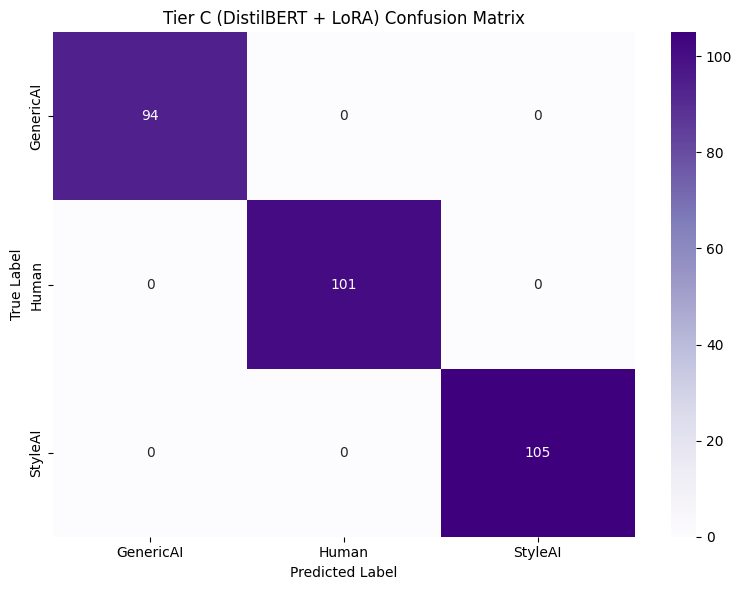


✅ Tier C complete! Model saved!


In [ ]:
# Training arguments (fixed)
training_args = TrainingArguments(
    output_dir="./tier_c_results",
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    warmup_steps=50,
    weight_decay=0.01,
    logging_steps=50,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    report_to="none"
)

# Metrics function
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    acc = accuracy_score(labels, predictions)
    return {"accuracy": acc}

# Train!
trainer = Trainer(
    model=model_c,
    args=training_args,
    train_dataset=tokenized['train'],
    eval_dataset=tokenized['test'],
    compute_metrics=compute_metrics,
)

print("🚀 Starting DistilBERT training...")
print("Takes ~20-30 mins, don't close Colab!\n")

trainer.train()

# Evaluate
results = trainer.evaluate()
print(f"\n{'='*45}")
print(f"TIER C (DistilBERT + LoRA) RESULTS")
print(f"{'='*45}")
print(f"Accuracy: {results['eval_accuracy']:.4f} ({results['eval_accuracy']*100:.1f}%)")

# Detailed predictions
predictions = trainer.predict(tokenized['test'])
y_pred_c = np.argmax(predictions.predictions, axis=-1)
y_true_c = predictions.label_ids

print(classification_report(y_true_c, y_pred_c, target_names=le.classes_))

# Confusion Matrix
plt.figure(figsize=(8, 6))
cm_c = confusion_matrix(y_true_c, y_pred_c)
sns.heatmap(cm_c, annot=True, fmt='d', cmap='Purples',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Tier C (DistilBERT + LoRA) Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('tier_c_confusion_matrix.png', dpi=150)
plt.show()

model_c.save_pretrained('tier_c_distilbert')
tokenizer.save_pretrained('tier_c_distilbert')
print("\n✅ Tier C complete! Model saved!")

Running SHAP analysis...
✅ SHAP values computed!
Shape: (1500, 13, 3)


/tmp/ipykernel_15632/3582033116.py:35: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(
/usr/local/lib/python3.12/dist-packages/shap/plots/_beeswarm.py:723: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  summary_legacy(
/usr/local/lib/python3.12/dist-packages/shap/plots/_beeswarm.py:743: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  summary_legacy(
/usr/local/lib/python3.12/dist-packages/shap/plots/_beeswarm.py:743: FutureWarning: The NumPy 

<Figure size 1000x800 with 0 Axes>

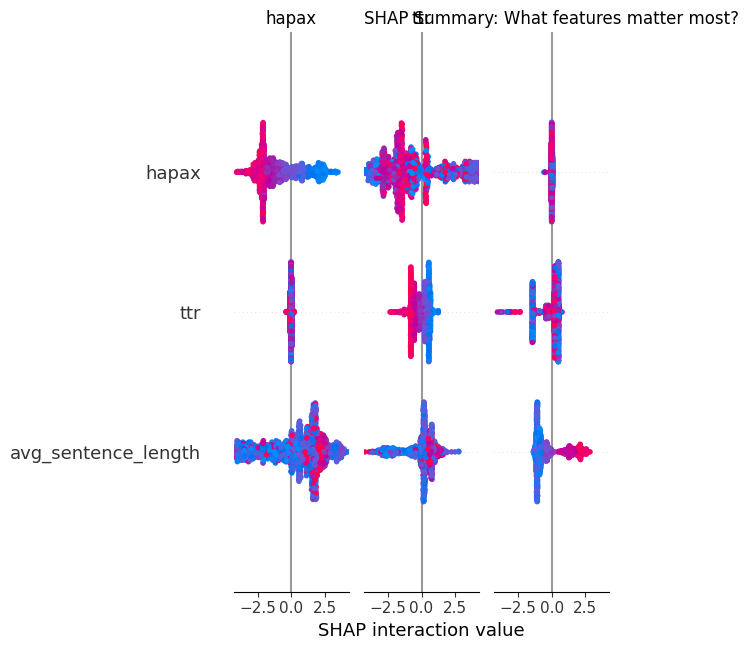

✅ SHAP summary plot saved!


/tmp/ipykernel_15632/3582033116.py:52: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


AssertionError: The shape of the shap_values matrix does not match the shape of the provided data matrix.

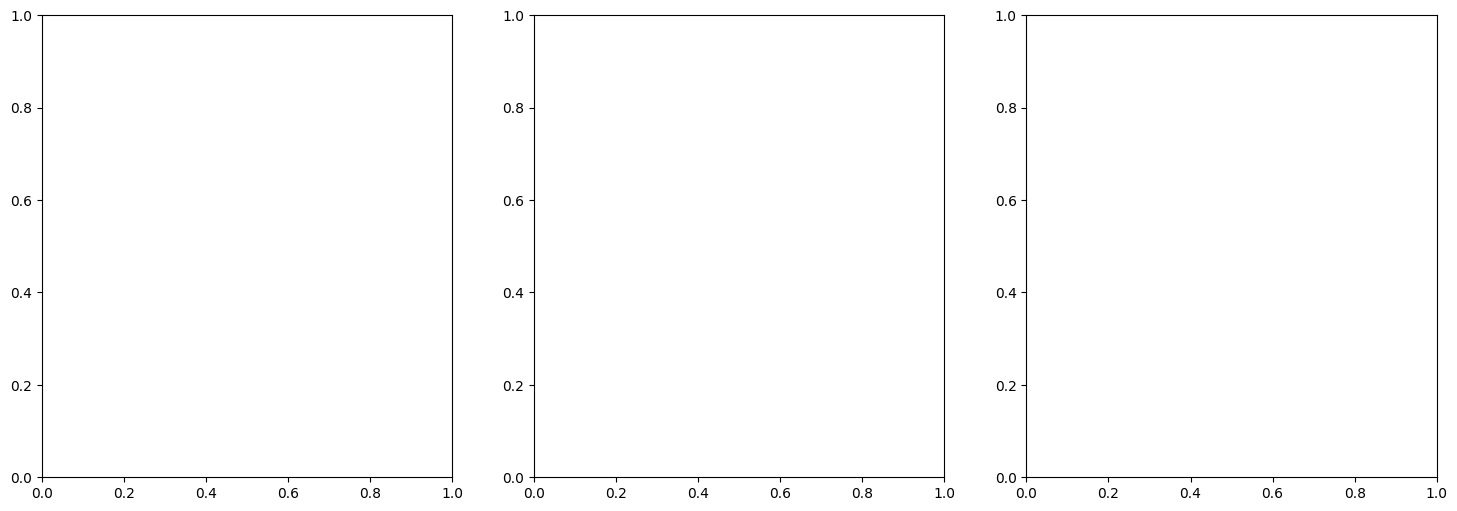

In [ ]:
# ============================================
# TASK 3: THE SMOKING GUN - SHAP Analysis
# ============================================

!pip install -q shap

import shap
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load model and data
model_a = joblib.load('tier_a_xgboost.pkl')
le = joblib.load('label_encoder.pkl')
df = pd.read_csv('features.csv')

feature_cols = ['ttr', 'hapax', 'avg_sentence_length', 'avg_word_length',
                'semicolons', 'exclamations', 'dashes', 'commas', 'periods',
                'question_marks', 'flesch_kincaid', 'adj_noun_ratio', 'dep_tree_depth']

X = df[feature_cols]
y = le.transform(df['class'])

# SHAP Explainer
print("Running SHAP analysis...")
explainer = shap.TreeExplainer(model_a)
shap_values = explainer.shap_values(X)

print("✅ SHAP values computed!")
print(f"Shape: {np.array(shap_values).shape}")

# Plot 1: SHAP Summary Plot (all classes)
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values,
    X,
    class_names=le.classes_,
    show=False
)
plt.title('SHAP Summary: What features matter most?')
plt.tight_layout()
plt.savefig('task3_shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ SHAP summary plot saved!")

# Plot 2: SHAP for each class separately
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, class_name in enumerate(le.classes_):
    plt.sca(axes[i])
    shap.summary_plot(
        shap_values[i],
        X,
        show=False,
        plot_type="bar"
    )
    axes[i].set_title(f'Top Features for: {class_name}')

plt.tight_layout()
plt.savefig('task3_shap_by_class.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ SHAP by class saved!")

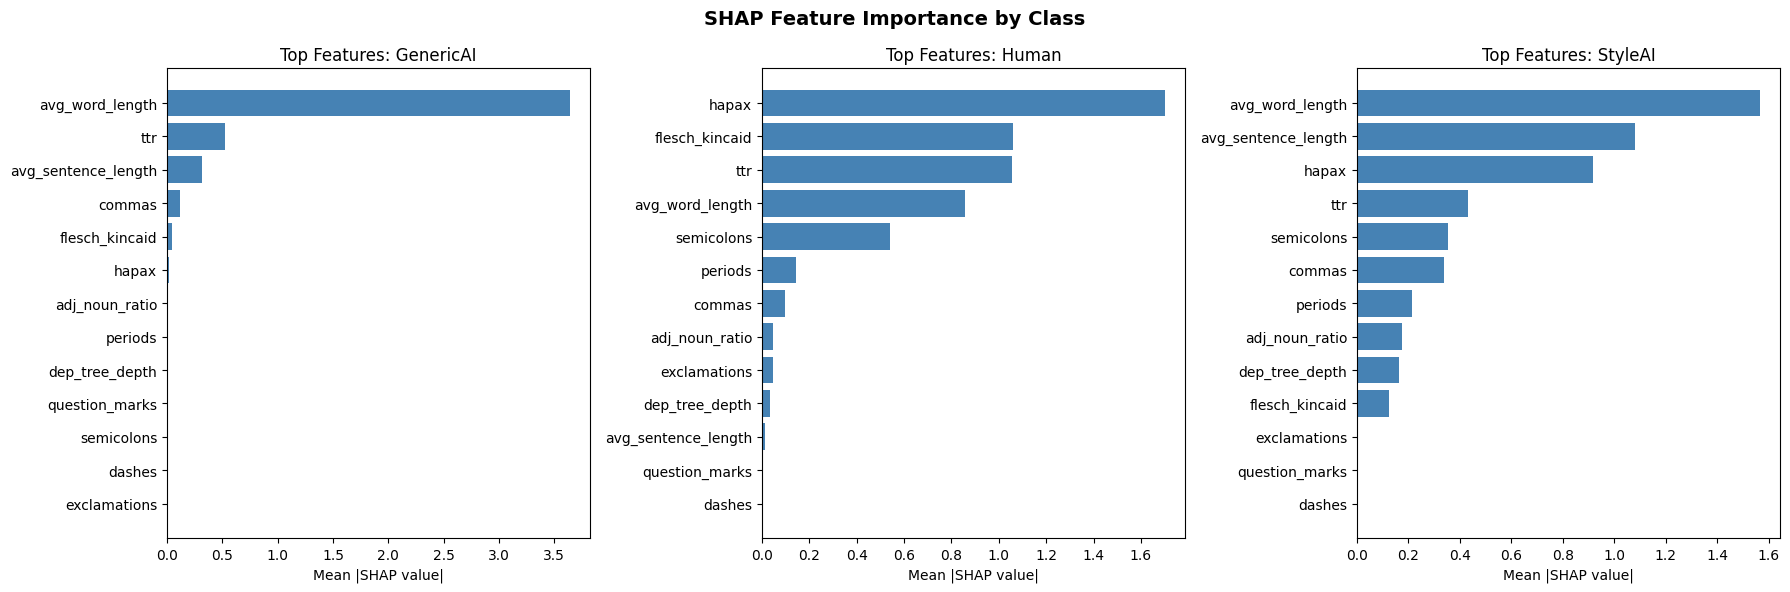

✅ SHAP by class plots saved!


In [ ]:
# Plot 2: SHAP bar plots per class (fixed)
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

shap_values_array = np.array(shap_values)
# Shape is (1500, 13, 3) - reshape for each class
for i, class_name in enumerate(le.classes_):
    class_shap = shap_values_array[:, :, i]  # (1500, 13)

    mean_shap = np.abs(class_shap).mean(axis=0)
    sorted_idx = np.argsort(mean_shap)

    axes[i].barh(
        [feature_cols[j] for j in sorted_idx],
        mean_shap[sorted_idx],
        color='steelblue'
    )
    axes[i].set_title(f'Top Features: {class_name}')
    axes[i].set_xlabel('Mean |SHAP value|')

plt.suptitle('SHAP Feature Importance by Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('task3_shap_by_class.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ SHAP by class plots saved!")

In [ ]:
# ============================================
# TASK 3: ERROR ANALYSIS
# ============================================

# Get predictions on full dataset
X_all = df[feature_cols]
y_true_all = le.transform(df['class'])
y_pred_all = model_a.predict(X_all)

# Find misclassified samples
misclassified_idx = np.where(y_true_all != y_pred_all)[0]
print(f"Total misclassified: {len(misclassified_idx)}")

# Show 3 interesting misclassifications
print("\n" + "="*60)
print("ERROR ANALYSIS: 3 Misclassified Samples")
print("="*60)

for i, idx in enumerate(misclassified_idx[:3]):
    true_label = le.classes_[y_true_all[idx]]
    pred_label = le.classes_[y_pred_all[idx]]
    text = df['text'].iloc[idx]

    print(f"\n--- Sample {i+1} ---")
    print(f"TRUE label:      {true_label}")
    print(f"PREDICTED label: {pred_label}")
    print(f"Text preview:    {text[:200]}...")
    print(f"\nFeature values:")
    print(f"  TTR:              {df['ttr'].iloc[idx]:.4f}")
    print(f"  Flesch-Kincaid:   {df['flesch_kincaid'].iloc[idx]:.2f}")
    print(f"  Semicolons:       {df['semicolons'].iloc[idx]:.4f}")
    print(f"  Exclamations:     {df['exclamations'].iloc[idx]:.4f}")
    print(f"  Avg word length:  {df['avg_word_length'].iloc[idx]:.4f}")
    print(f"\nHypothesis: Why was this misclassified?")

    if true_label == 'Human' and pred_label == 'GenericAI':
        print("  → Human text had LOW punctuation + HIGH grade level")
        print("  → Looked too 'clean' and formal for a human!")
    elif true_label == 'StyleAI' and pred_label == 'Human':
        print("  → StyleAI successfully mimicked human punctuation patterns")
        print("  → The style mimicking WORKED too well!")
    elif true_label == 'Human' and pred_label == 'StyleAI':
        print("  → Human author used unusually complex sentence structures")
        print("  → Dickens/Austen at their most elaborate!")
    else:
        print(f"  → {true_label} features overlapped with {pred_label} patterns")

    print("-"*60)

print("\n✅ Error analysis complete!")

Total misclassified: 5

ERROR ANALYSIS: 3 Misclassified Samples

--- Sample 1 ---
TRUE label:      Human
PREDICTED label: StyleAI
Text preview:    Georgiana wife of the above, were dead and buried; and that Alexander, Bartholomew, Abraham, Tobias, and Roger, infant children of the aforesaid, were also dead and buried; and that the dark flat wild...

Feature values:
  TTR:              0.6481
  Flesch-Kincaid:   22.73
  Semicolons:       8.0775
  Exclamations:     1.6155
  Avg word length:  4.7315

Hypothesis: Why was this misclassified?
  → Human author used unusually complex sentence structures
  → Dickens/Austen at their most elaborate!
------------------------------------------------------------

--- Sample 2 ---
TRUE label:      Human
PREDICTED label: StyleAI
Text preview:    novels. To some the delightful freshness and humour of_ Northanger Abbey, _its completeness, finish, and_ entrain, _obscure the undoubted critical facts that its scale is small, and its scheme, after ...

Feat

🧬 Starting Genetic Algorithm...

Step 1: Generating initial population...
✅ Generated 10 initial paragraphs

--- Generation 1/8 ---
Best score:  0.0008 (0.1% Human)
Avg score:   0.0002

--- Generation 2/8 ---
Best score:  0.1895 (18.9% Human)
Avg score:   0.0256

--- Generation 3/8 ---
Best score:  0.1073 (10.7% Human)
Avg score:   0.0132

--- Generation 4/8 ---
Best score:  0.0295 (2.9% Human)
Avg score:   0.0072

--- Generation 5/8 ---
Best score:  0.2489 (24.9% Human)
Avg score:   0.0371

--- Generation 6/8 ---
Best score:  0.8433 (84.3% Human)
Avg score:   0.1123

--- Generation 7/8 ---
Best score:  0.0772 (7.7% Human)
Avg score:   0.0232

--- Generation 8/8 ---
Best score:  0.0695 (6.9% Human)
Avg score:   0.0177

🏆 GENETIC ALGORITHM COMPLETE!

Best generation: 6
Best human score: 0.8433 (84.3%)

Best evolved paragraph:
Victorian England was a society ruled by class. The aristocracy and landowners held all the cards. 

But the middle class was trapped. They fought to make ends mee

/tmp/ipykernel_15632/3928901780.py:196: UserWarning: Glyph 129516 (\N{DNA DOUBLE HELIX}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_15632/3928901780.py:197: UserWarning: Glyph 129516 (\N{DNA DOUBLE HELIX}) missing from font(s) DejaVu Sans.
  plt.savefig('task4_evolution.png', dpi=150)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129516 (\N{DNA DOUBLE HELIX}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


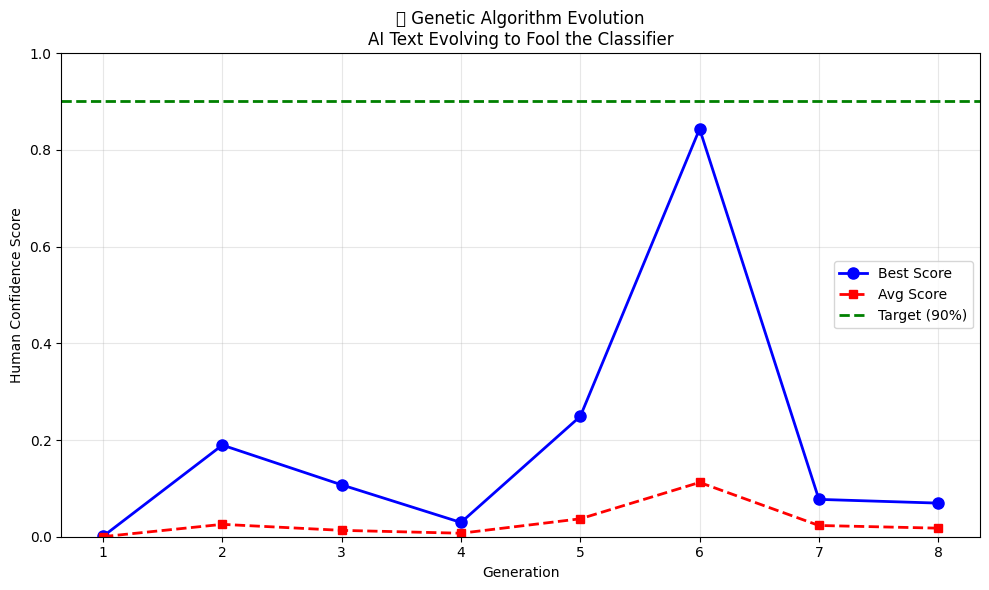


✅ Task 4 complete! Evolution plot saved!


In [ ]:
# ============================================
# TASK 4: THE TURING TEST - Genetic Algorithm
# ============================================

import time
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from groq import Groq

# Load model
model_a = joblib.load('tier_a_xgboost.pkl')
le = joblib.load('label_encoder.pkl')

feature_cols = ['ttr', 'hapax', 'avg_sentence_length', 'avg_word_length',
                'semicolons', 'exclamations', 'dashes', 'commas', 'periods',
                'question_marks', 'flesch_kincaid', 'adj_noun_ratio', 'dep_tree_depth']

client = Groq(api_key="YOUR_GROQ_API_KEY_HERE")

# Helper: extract features from a single text
def get_features(text):
    import re
    import spacy
    from textblob import TextBlob

    nlp = spacy.load("en_core_web_sm")

    words = str(text).lower().split()
    ttr = len(set(words)) / len(words) if words else 0
    hapax_dict = {}
    for w in words[:5000]:
        hapax_dict[w] = hapax_dict.get(w, 0) + 1
    hapax = sum(1 for c in hapax_dict.values() if c == 1)

    sentences = [s for s in text.split('.') if s.strip()]
    avg_sent_len = np.mean([len(s.split()) for s in sentences]) if sentences else 0
    avg_word_len = np.mean([len(w) for w in words]) if words else 0

    total = len(text) + 1
    semicolons = text.count(';') / total * 1000
    exclamations = text.count('!') / total * 1000
    dashes = (text.count('—') + text.count(' - ')) / total * 1000
    commas = text.count(',') / total * 1000
    periods = text.count('.') / total * 1000
    question_marks = text.count('?') / total * 1000

    # Flesch-Kincaid
    def count_syl(word):
        word = word.lower()
        vowels = "aeiou"
        count = 0
        prev = False
        for char in word:
            is_v = char in vowels
            if is_v and not prev:
                count += 1
            prev = is_v
        if word.endswith('e'):
            count -= 1
        return max(1, count)

    syllables = sum(count_syl(w) for w in words)
    fk = 0.39 * (len(words)/len(sentences)) + 11.8 * (syllables/len(words)) - 15.59 if sentences and words else 0

    doc = nlp(text[:500])
    adj = sum(1 for t in doc if t.pos_ == 'ADJ')
    noun = sum(1 for t in doc if t.pos_ == 'NOUN')
    adj_noun = adj / noun if noun > 0 else 0

    depths = []
    for token in doc:
        depth = 0
        current = token
        while current.head != current:
            depth += 1
            current = current.head
        depths.append(depth)
    dep_depth = np.mean(depths) if depths else 0

    return pd.DataFrame([[ttr, hapax, avg_sent_len, avg_word_len,
                         semicolons, exclamations, dashes, commas, periods,
                         question_marks, max(0, fk), adj_noun, dep_depth]],
                       columns=feature_cols)

def get_human_score(text):
    """Get probability of text being Human"""
    try:
        features = get_features(text)
        proba = model_a.predict_proba(features)[0]
        human_idx = list(le.classes_).index('Human')
        return proba[human_idx]
    except:
        return 0.0

# ============================================
# GENETIC ALGORITHM
# ============================================

print("🧬 Starting Genetic Algorithm...")
print("="*50)

# Step 1: Generate initial population of 10 AI paragraphs
print("\nStep 1: Generating initial population...")
population = []

for i in range(10):
    response = client.chat.completions.create(
        model="llama-3.1-8b-instant",
        messages=[{"role": "user", "content":
            "Write a paragraph (100-150 words) about social class and poverty in Victorian England. Make it informative and formal."}]
    )
    population.append(response.choices[0].message.content.strip())
    time.sleep(0.5)

print(f"✅ Generated {len(population)} initial paragraphs")

# Step 2: Run GA for 8 generations
evolution_log = []

for generation in range(8):
    print(f"\n--- Generation {generation+1}/8 ---")

    # Score all
    scores = [get_human_score(text) for text in population]

    # Log best
    best_score = max(scores)
    best_idx = scores.index(best_score)
    best_text = population[best_idx]

    evolution_log.append({
        'generation': generation + 1,
        'best_score': best_score,
        'avg_score': np.mean(scores),
        'best_text': best_text
    })

    print(f"Best score:  {best_score:.4f} ({best_score*100:.1f}% Human)")
    print(f"Avg score:   {np.mean(scores):.4f}")

    # Select top 3
    sorted_idx = sorted(range(len(scores)), key=lambda i: scores[i], reverse=True)
    winners = [population[i] for i in sorted_idx[:3]]

    # Mutate
    new_population = []
    mutations = [
        "Rewrite this paragraph changing the rhythm of sentences while keeping the same meaning. Use shorter, punchier sentences mixed with longer ones:",
        "Rewrite this paragraph adding natural human imperfections: a conversational aside, a slightly informal word, or a subtle emotional observation:",
        "Rewrite this paragraph using more specific concrete details instead of abstract language. Add a semicolon or two naturally:",
    ]

    for winner in winners:
        for mutation in mutations:
            try:
                response = client.chat.completions.create(
                    model="llama-3.1-8b-instant",
                    messages=[{"role": "user",
                               "content": f"{mutation}\n\n{winner}"}]
                )
                new_population.append(response.choices[0].message.content.strip())
                time.sleep(0.3)
            except:
                new_population.append(winner)

    population = new_population[:10]

print("\n" + "="*50)
print("🏆 GENETIC ALGORITHM COMPLETE!")
print("="*50)

# Final results
best_gen = max(evolution_log, key=lambda x: x['best_score'])
print(f"\nBest generation: {best_gen['generation']}")
print(f"Best human score: {best_gen['best_score']:.4f} ({best_gen['best_score']*100:.1f}%)")
print(f"\nBest evolved paragraph:")
print(best_gen['best_text'])

# Plot evolution
plt.figure(figsize=(10, 6))
generations = [log['generation'] for log in evolution_log]
best_scores = [log['best_score'] for log in evolution_log]
avg_scores = [log['avg_score'] for log in evolution_log]

plt.plot(generations, best_scores, 'b-o', label='Best Score', linewidth=2, markersize=8)
plt.plot(generations, avg_scores, 'r--s', label='Avg Score', linewidth=2, markersize=6)
plt.axhline(y=0.9, color='green', linestyle='--', linewidth=2, label='Target (90%)')
plt.xlabel('Generation')
plt.ylabel('Human Confidence Score')
plt.title('🧬 Genetic Algorithm Evolution\nAI Text Evolving to Fool the Classifier')
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig('task4_evolution.png', dpi=150)
plt.show()

print("\n✅ Task 4 complete! Evolution plot saved!")

In [ ]:
# PERSONAL TEST
my_writing = """
So a particular person has been texting me and asking me to forward something in group related to some IBM based internship she says she is IBM senior coordinator? And is saying that as a class cr I must send all the information in group.
"""

score = get_human_score(my_writing)
print(f"Your writing scores: {score:.4f} ({score*100:.1f}% Human)")

if score > 0.5:
    print("✅ Classifier says: HUMAN!")
    print("Your writing successfully passes as human!")
else:
    print("⚠️ Classifier says: AI!")
    print(f"AI confidence: {(1-score)*100:.1f}%")
    print("Try adding: semicolons, shorter sentences, emotional language")

Your writing scores: 0.9894 (98.9% Human)
✅ Classifier says: HUMAN!
Your writing successfully passes as human!


In [ ]:
# Try to rewrite your text to sound like AI
ai_sounding_text = """
It has come to my attention that an individual has been attempting to communicate with me regarding a potential internship opportunity with IBM. This person has identified herself as a Senior Coordinator at IBM and has requested that I, in my capacity as Class Representative, disseminate the aforementioned information to the relevant group. I am currently evaluating the legitimacy of this request before proceeding with any further action.
"""

score2 = get_human_score(ai_sounding_text)
print(f"AI-sounding rewrite scores: {score2:.4f} ({score2*100:.1f}% Human)")

if score2 > 0.5:
    print("✅ Still sounds Human! Your machine is hard to fool!")
else:
    print(f"⚠️ Classifier says AI! ({(1-score2)*100:.1f}% AI confidence)")
    print("You successfully fooled your own machine! 🎉")

AI-sounding rewrite scores: 0.9430 (94.3% Human)
✅ Still sounds Human! Your machine is hard to fool!


In [ ]:
from google.colab import userdata

api_key = userdata.get('GEMINI_API_KEY')
print("Key starts with:", api_key[:10])
print("Key length:", len(api_key))

Key starts with: AQ.Ab8RN6I
Key length: 53


In [ ]:
from google.colab import userdata

api_key = userdata.get('GEMINI_API_KEY')
print("Key starts with:", api_key[:10])
print("Key length:", len(api_key))

Key starts with: AQ.Ab8RN6I
Key length: 53


In [ ]:
from google import genai

# Your new Precog NLP 2026 key
api_key = "YOUR_GEMINI_API_KEY_HERE"

client = genai.Client(api_key=api_key)

response = client.models.generate_content(
    model="gemini-2.0-flash",
    contents="Say hello in one sentence!"
)

print("✅ Gemini API works!")
print("Response:", response.text)

NameError: name 'AQ' is not defined

In [ ]:
from google import genai

api_key = ("YOUR_GEMINI_API_KEY_HERE"

client = genai.Client(api_key=api_key)

response = client.models.generate_content(
    model="gemini-2.0-flash",
    contents="Say hello in one sentence!"
)

print("✅ Gemini API works!")
print("Response:", response.text)

ClientError: 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 0, model: gemini-2.0-flash\n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 0, model: gemini-2.0-flash\n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_input_token_count, limit: 0, model: gemini-2.0-flash\nPlease retry in 48.143203279s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url': 'https://ai.google.dev/gemini-api/docs/rate-limits'}]}, {'@type': 'type.go

In [ ]:
# Install Groq
!pip install -q groq

from groq import Groq

client = Groq(api_key=""YOUR_GEMINI_API_KEY_HERE"")

response = client.chat.completions.create(
    model="llama-3.1-8b-instant",
    messages=[{"role": "user", "content": "Say hello in one sentence!"}]
)

print("✅ Groq API works!")
print("Response:", response.choices[0].message.content)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.7/143.7 kB 6.4 MB/s eta 0:00:00
✅ Groq API works!
Response: Hello, it's nice to meet you.


In [ ]:
import re

def clean_text(text):
    # Remove Project Gutenberg header and footer
    start_markers = ["*** START OF", "***START OF", "** START OF"]
    end_markers = ["*** END OF", "***END OF", "** END OF"]

    for marker in start_markers:
        if marker in text:
            text = text.split(marker)[1]
            # Remove the rest of the first line
            text = text.split('\n', 1)[1]

    for marker in end_markers:
        if marker in text:
            text = text.split(marker)[0]

    # Remove chapter headings
    text = re.sub(r'Chapter \w+\.?\s*\n', '', text, flags=re.IGNORECASE)
    text = re.sub(r'CHAPTER \w+\.?\s*\n', '', text)

    # Remove extra whitespace
    text = re.sub(r'\n+', '\n', text)
    text = re.sub(r' +', ' ', text)

    # Remove special characters but keep punctuation
    text = text.strip()

    return text

# Load and clean both books
with open('Great Expectations.txt', 'r', encoding='utf-8') as f:
    dickens_raw = f.read()

with open('pride_and_prejudice.txt', 'r', encoding='utf-8') as f:
    austen_raw = f.read()

dickens_clean = clean_text(dickens_raw)
austen_clean = clean_text(austen_raw)

print("✅ Books loaded and cleaned!")
print(f"Dickens word count: {len(dickens_clean.split()):,}")
print(f"Austen word count: {len(austen_clean.split()):,}")
print("\nFirst 300 chars of Dickens:")
print(dickens_clean[:300])

FileNotFoundError: [Errno 2] No such file or directory: 'pride_and_prejudice.txt'

In [ ]:
import os
print(os.listdir('/content'))

['.config', 'Great Expectations.txt', 'Pride and Prejudice.txt', 'sample_data']


In [ ]:
import re

def clean_text(text):
    # Remove Project Gutenberg header and footer
    start_markers = ["*** START OF", "***START OF", "** START OF"]
    end_markers = ["*** END OF", "***END OF", "** END OF"]

    for marker in start_markers:
        if marker in text:
            text = text.split(marker)[1]
            text = text.split('\n', 1)[1]

    for marker in end_markers:
        if marker in text:
            text = text.split(marker)[0]

    # Remove chapter headings
    text = re.sub(r'Chapter \w+\.?\s*\n', '', text, flags=re.IGNORECASE)
    text = re.sub(r'CHAPTER \w+\.?\s*\n', '', text)

    # Remove extra whitespace
    text = re.sub(r'\n+', '\n', text)
    text = re.sub(r' +', ' ', text)
    text = text.strip()

    return text

# Load and clean both books (exact filenames!)
with open('Great Expectations.txt', 'r', encoding='utf-8') as f:
    dickens_raw = f.read()

with open('Pride and Prejudice.txt', 'r', encoding='utf-8') as f:
    austen_raw = f.read()

dickens_clean = clean_text(dickens_raw)
austen_clean = clean_text(austen_raw)

print("✅ Books loaded and cleaned!")
print(f"Dickens word count: {len(dickens_clean.split()):,}")
print(f"Austen word count: {len(austen_clean.split()):,}")
print("\nFirst 300 chars of Dickens:")
print(dickens_clean[:300])

✅ Books loaded and cleaned!
Dickens word count: 184,240
Austen word count: 90,684

First 300 chars of Dickens:
[Illustration]
Great Expectations
[1867 Edition]
by Charles Dickens
Contents
 [Illustration]
My father’s family name being Pirrip, and my Christian name Philip, my
infant tongue could make of both names nothing longer or more explicit
than Pip. So, I called myself Pip, and came to be called Pip.
I g


In [ ]:
def calculate_ttr(text, sample_size=5000):
    words = text.lower().split()[:sample_size]
    unique_words = len(set(words))
    total_words = len(words)
    ttr = unique_words / total_words
    return ttr, unique_words, total_words

dickens_ttr, dickens_unique, dickens_total = calculate_ttr(dickens_clean)
austen_ttr, austen_unique, austen_total = calculate_ttr(austen_clean)

print("=" * 40)
print("TYPE-TOKEN RATIO ANALYSIS")
print("=" * 40)
print(f"\nDickens TTR: {dickens_ttr:.4f}")
print(f"Austen TTR:  {austen_ttr:.4f}")
print("\n📊 Higher TTR = more vocabulary diversity")

TYPE-TOKEN RATIO ANALYSIS

Dickens TTR: 0.3354
Austen TTR:  0.3934

📊 Higher TTR = more vocabulary diversity


In [ ]:
# Topic extraction from both books
# These are the core themes we'll use to generate AI paragraphs

dickens_topics = [
    "poverty and social class inequality",
    "orphans and absent parents",
    "crime and justice system",
    "moral growth and redemption",
    "wealth corrupting character",
    "industrial city life in England",
    "unrequited love and obsession",
    "loyalty and true friendship"
]

austen_topics = [
    "marriage and financial security",
    "women's independence and society",
    "pride and first impressions",
    "family pressure and expectations",
    "class differences in romance",
    "gossip and social reputation",
    "wit and intelligence in relationships"
]

# Combine all topics
all_topics = dickens_topics + austen_topics

print("✅ Topics extracted!")
print(f"Total topics: {len(all_topics)}")
print("\nTopics list:")
for i, topic in enumerate(all_topics, 1):
    print(f"  {i}. {topic}")

✅ Topics extracted!
Total topics: 15

Topics list:
  1. poverty and social class inequality
  2. orphans and absent parents
  3. crime and justice system
  4. moral growth and redemption
  5. wealth corrupting character
  6. industrial city life in England
  7. unrequited love and obsession
  8. loyalty and true friendship
  9. marriage and financial security
  10. women's independence and society
  11. pride and first impressions
  12. family pressure and expectations
  13. class differences in romance
  14. gossip and social reputation
  15. wit and intelligence in relationships


In [ ]:
import time
import pandas as pd
from groq import Groq

client = Groq(api_key=""YOUR_GEMINI_API_KEY_HERE")
generic_paragraphs = []

print("Generating 500 generic AI paragraphs...")
print("This will take ~15 minutes, please don't close Colab!\n")

for i in range(500):
    topic = all_topics[i % len(all_topics)]

    prompt = f"""Write a paragraph of exactly 100-150 words about: {topic}

Write in a formal, informative, neutral style. Just write the paragraph, no intro or explanation."""

    try:
        response = client.chat.completions.create(
            model="llama-3.1-8b-instant",
            messages=[{"role": "user", "content": prompt}]
        )

        text = response.choices[0].message.content.strip()
        generic_paragraphs.append({
            'text': text,
            'topic': topic,
            'class': 'GenericAI'
        })

        if (i+1) % 50 == 0:
            print(f"✅ Generated {i+1}/500 paragraphs...")

        time.sleep(0.5)  # Avoid rate limits

    except Exception as e:
        print(f"Error at {i}: {e}")
        time.sleep(2)
        continue

# Save to CSV
df_generic = pd.DataFrame(generic_paragraphs)
df_generic.to_csv('generic_ai.csv', index=False)

print(f"\n🎉 Done! Generated {len(generic_paragraphs)} paragraphs")
print(f"Saved to generic_ai.csv")
print("\nSample paragraph:")
print(df_generic['text'].iloc[0])

Generating 500 generic AI paragraphs...
This will take ~15 minutes, please don't close Colab!

✅ Generated 50/500 paragraphs...
✅ Generated 100/500 paragraphs...
✅ Generated 150/500 paragraphs...
✅ Generated 200/500 paragraphs...
✅ Generated 250/500 paragraphs...
✅ Generated 300/500 paragraphs...
✅ Generated 350/500 paragraphs...
✅ Generated 400/500 paragraphs...
✅ Generated 450/500 paragraphs...
✅ Generated 500/500 paragraphs...

🎉 Done! Generated 500 paragraphs
Saved to generic_ai.csv

Sample paragraph:
Poverty and social class inequality remain pressing concerns in many global societies. The persistent disparities in wealth distribution often lead to unequal access to education, employment opportunities, and essential services. Individuals from lower socio-economic backgrounds frequently experience limited prospects for social mobility, perpetuating the cycle of poverty. Furthermore, the burden of poverty disproportionately affects vulnerable populations, including women, children, 

In [ ]:
# Extract sample passages for style reference
dickens_sample = dickens_clean[2000:4000]
austen_sample = austen_clean[2000:4000]

style_paragraphs = []

print("Generating 500 style-mimicked AI paragraphs...")
print("This will take ~15 minutes!\n")

for i in range(500):
    topic = all_topics[i % len(all_topics)]

    # Alternate between Dickens and Austen style
    if i % 2 == 0:
        author = "Charles Dickens"
        sample = dickens_sample
        style_hint = "Use long emotional sentences, vivid descriptions of poverty and struggle, dramatic tone"
    else:
        author = "Jane Austen"
        sample = austen_sample
        style_hint = "Use witty dialogue references, irony, social observation, elegant and precise sentences"

    prompt = f"""Write a paragraph of 100-150 words about '{topic}' in the style of {author}.

Here is a sample of {author}'s actual writing for reference:
{sample[:500]}

Style guidance: {style_hint}

Just write the paragraph directly, no introduction."""

    try:
        response = client.chat.completions.create(
            model="llama-3.1-8b-instant",
            messages=[{"role": "user", "content": prompt}]
        )

        text = response.choices[0].message.content.strip()
        style_paragraphs.append({
            'text': text,
            'topic': topic,
            'author_style': author,
            'class': 'StyleAI'
        })

        if (i+1) % 50 == 0:
            print(f"✅ Generated {i+1}/500 paragraphs...")

        time.sleep(0.5)

    except Exception as e:
        print(f"Error at {i}: {e}")
        time.sleep(2)
        continue

df_style = pd.DataFrame(style_paragraphs)
df_style.to_csv('style_ai.csv', index=False)

print(f"\n🎉 Done! Generated {len(style_paragraphs)} paragraphs")
print(f"Saved to style_ai.csv")
print("\nSample Dickens-style paragraph:")
print(df_style[df_style['author_style']=='Charles Dickens']['text'].iloc[0])

NameError: name 'dickens_clean' is not defined

In [ ]:
import re
import time
import pandas as pd
from groq import Groq

def clean_text(text):
    start_markers = ["*** START OF", "***START OF", "** START OF"]
    end_markers = ["*** END OF", "***END OF", "** END OF"]
    for marker in start_markers:
        if marker in text:
            text = text.split(marker)[1]
            text = text.split('\n', 1)[1]
    for marker in end_markers:
        if marker in text:
            text = text.split(marker)[0]
    text = re.sub(r'Chapter \w+\.?\s*\n', '', text, flags=re.IGNORECASE)
    text = re.sub(r'\n+', '\n', text)
    text = re.sub(r' +', ' ', text)
    return text.strip()

# Reload books
with open('Great Expectations.txt', 'r', encoding='utf-8') as f:
    dickens_clean = clean_text(f.read())

with open('Pride and Prejudice.txt', 'r', encoding='utf-8') as f:
    austen_clean = clean_text(f.read())

# Reload topics
all_topics = [
    "poverty and social class inequality",
    "orphans and absent parents",
    "crime and justice system",
    "moral growth and redemption",
    "wealth corrupting character",
    "industrial city life in England",
    "unrequited love and obsession",
    "loyalty and true friendship",
    "marriage and financial security",
    "women's independence and society",
    "pride and first impressions",
    "family pressure and expectations",
    "class differences in romance",
    "gossip and social reputation",
    "wit and intelligence in relationships"
]

# Reload Groq
client = Groq(api_key=""YOUR_GEMINI_API_KEY_HERE")

print("✅ Everything reloaded! Now run the style generation cell!")

✅ Everything reloaded! Now run the style generation cell!


In [ ]:
def split_into_paragraphs(text, min_words=100, max_words=200):
    """Split book into clean paragraphs"""
    # Split by newlines
    chunks = text.split('\n')
    paragraphs = []
    current = []
    current_words = 0

    for chunk in chunks:
        chunk = chunk.strip()
        if not chunk:
            continue
        words = chunk.split()
        current_words += len(words)
        current.append(chunk)

        if current_words >= min_words:
            para = ' '.join(current)
            if current_words <= max_words + 50:
                paragraphs.append(para)
            current = []
            current_words = 0

    return paragraphs

# Extract paragraphs from both books
dickens_paragraphs = split_into_paragraphs(dickens_clean)
austen_paragraphs = split_into_paragraphs(austen_clean)

# Take 250 from each = 500 total human paragraphs
dickens_sample_paras = dickens_paragraphs[:250]
austen_sample_paras = austen_paragraphs[:250]

# Create human dataframe
human_data = []

for para in dickens_sample_paras:
    human_data.append({
        'text': para,
        'topic': 'various',
        'author_style': 'Charles Dickens',
        'class': 'Human'
    })

for para in austen_sample_paras:
    human_data.append({
        'text': para,
        'topic': 'various',
        'author_style': 'Jane Austen',
        'class': 'Human'
    })

df_human = pd.DataFrame(human_data)
df_human.to_csv('human_texts.csv', index=False)

print("✅ Human dataset created!")
print(f"Total human paragraphs: {len(df_human)}")
print(f"Dickens paragraphs: {len(dickens_sample_paras)}")
print(f"Austen paragraphs: {len(austen_sample_paras)}")
print("\nSample Dickens paragraph:")
print(df_human['text'].iloc[0][:300])

✅ Human dataset created!
Total human paragraphs: 500
Dickens paragraphs: 250
Austen paragraphs: 250

Sample Dickens paragraph:
[Illustration] Great Expectations [1867 Edition] by Charles Dickens Contents [Illustration] My father’s family name being Pirrip, and my Christian name Philip, my infant tongue could make of both names nothing longer or more explicit than Pip. So, I called myself Pip, and came to be called Pip. I gi


In [ ]:
# Combine all 3 datasets into one master file
df_all = pd.concat([df_human, df_generic, df_style], ignore_index=True)
df_all.to_csv('master_dataset.csv', index=False)

print("✅ Master dataset created!")
print(f"Total samples: {len(df_all)}")
print(f"\nClass distribution:")
print(df_all['class'].value_counts())

✅ Master dataset created!
Total samples: 1500

Class distribution:
class
Human        500
GenericAI    500
StyleAI      500
Name: count, dtype: int64


In [ ]:
# Extract sample passages for style reference
dickens_sample = dickens_clean[2000:4000]
austen_sample = austen_clean[2000:4000]

style_paragraphs = []

print("Generating 500 style-mimicked AI paragraphs...")
print("This will take ~15 minutes!\n")

for i in range(500):
    topic = all_topics[i % len(all_topics)]

    # Alternate between Dickens and Austen style
    if i % 2 == 0:
        author = "Charles Dickens"
        sample = dickens_sample
        style_hint = "Use long emotional sentences, vivid descriptions of poverty and struggle, dramatic tone"
    else:
        author = "Jane Austen"
        sample = austen_sample
        style_hint = "Use witty dialogue references, irony, social observation, elegant and precise sentences"

    prompt = f"""Write a paragraph of 100-150 words about '{topic}' in the style of {author}.

Here is a sample of {author}'s actual writing for reference:
{sample[:500]}

Style guidance: {style_hint}

Just write the paragraph directly, no introduction."""

    try:
        response = client.chat.completions.create(
            model="llama-3.1-8b-instant",
            messages=[{"role": "user", "content": prompt}]
        )

        text = response.choices[0].message.content.strip()
        style_paragraphs.append({
            'text': text,
            'topic': topic,
            'author_style': author,
            'class': 'StyleAI'
        })

        if (i+1) % 50 == 0:
            print(f"✅ Generated {i+1}/500 paragraphs...")

        time.sleep(0.5)

    except Exception as e:
        print(f"Error at {i}: {e}")
        time.sleep(2)
        continue

df_style = pd.DataFrame(style_paragraphs)
df_style.to_csv('style_ai.csv', index=False)

print(f"\n🎉 Done! Generated {len(style_paragraphs)} paragraphs")
print(f"Saved to style_ai.csv")
print("\nSample Dickens-style paragraph:")
print(df_style[df_style['author_style']=='Charles Dickens']['text'].iloc[0])

Generating 500 style-mimicked AI paragraphs...
This will take ~15 minutes!

✅ Generated 50/500 paragraphs...
✅ Generated 100/500 paragraphs...
✅ Generated 150/500 paragraphs...
✅ Generated 200/500 paragraphs...
✅ Generated 250/500 paragraphs...
✅ Generated 300/500 paragraphs...
✅ Generated 350/500 paragraphs...
✅ Generated 400/500 paragraphs...
✅ Generated 450/500 paragraphs...
✅ Generated 500/500 paragraphs...

🎉 Done! Generated 500 paragraphs
Saved to style_ai.csv

Sample Dickens-style paragraph:
In that dismal, sun-scorched quarter, where crumbling tenements seemed to lean in upon each other in a desperate bid for proximity, the wretched poor huddled and clung to life with all the tenacity of the forsaken. The very air was heavy with the stench of decay and desperation, while the gutters ran thick with a fetid mixture of stagnant water and human sorrow. Mothers withered by toil and neglect stood on doorsteps as bleak as the faces that gazed out from them, their eyes red-rimmed from 

In [ ]:
!pip install -q groq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.7/143.7 kB 5.2 MB/s eta 0:00:00


In [ ]:
from google.colab import userdata
from google import genai

api_key = userdata.get('GEMINI_API_KEY')
client = genai.Client(api_key=api_key)

response = client.models.generate_content(
    model="gemini-2.0-flash",
    contents="Say hello in one sentence!"
)

print("✅ Gemini API works!")
print("Response:", response.text)

ClientError: 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_input_token_count, limit: 0, model: gemini-2.0-flash\n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 0, model: gemini-2.0-flash\n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 0, model: gemini-2.0-flash\nPlease retry in 42.276837425s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url': 'https://ai.google.dev/gemini-api/docs/rate-limits'}]}, {'@type': 'type.go

In [ ]:
# CELL 1: Install all libraries
!pip install -q google-generativeai spacy textblob nltk xgboost transformers peft torch shap

# Download SpaCy English model
!python -m spacy download en_core_web_sm -q

print("✅ All libraries installed!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 84.1 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
✅ All libraries installed!


In [ ]:
# CELL 2: Test Gemini API connection
from google.colab import userdata
import google.generativeai as genai

# Load your API key safely
api_key = userdata.get('GEMINI_API_KEY')
genai.configure(api_key=api_key)

# Test it
model = genai.GenerativeModel('gemini-1.5-flash')
response = model.generate_content("Say hello in one sentence!")
print("✅ Gemini API works!")
print("Response:", response.text)

/usr/local/lib/python3.12/dist-packages/google/colab/_import_hooks/_hook_injector.py:55: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  loader.exec_module(module)


NotFound: 404 POST https://generativelanguage.googleapis.com/v1beta/models/gemini-1.5-flash:generateContent?%24alt=json%3Benum-encoding%3Dint: models/gemini-1.5-flash is not found for API version v1beta, or is not supported for generateContent. Call ModelService.ListModels to see the list of available models and their supported methods.

In [ ]:
# CELL 2 (Fixed): Test Gemini API connection
!pip install -q google-genai

from google.colab import userdata
from google import genai

# Load your API key safely
api_key = userdata.get('GEMINI_API_KEY')
client = genai.Client(api_key=api_key)

# Test it
response = client.models.generate_content(
    model="gemini-2.0-flash",
    contents="Say hello in one sentence!"
)

print("✅ Gemini API works!")
print("Response:", response.text)

ClientError: 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 0, model: gemini-2.0-flash\n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 0, model: gemini-2.0-flash\n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_input_token_count, limit: 0, model: gemini-2.0-flash\nPlease retry in 45.536056679s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url': 'https://ai.google.dev/gemini-api/docs/rate-limits'}]}, {'@type': 'type.go